# Vaccine usage perdiction- Logistic regression project

### 1. Import libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.linear_model import SGDClassifier

import statsmodels
import statsmodels.api as sm

plt.rcParams['figure.figsize']= [15, 8]

In [2]:
# use below code to convert the 'exponential' values to float
np.set_printoptions(suppress = True)

### 2. Read data

In [3]:
data= pd.read_csv(r'C:\Users\SAMBIT\OneDrive\Desktop\Imarticus\Extra projects\ML + python project\h1n1_vaccine_prediction.csv')

data.head()

,unique_id,h1n1_worry,h1n1_awareness,antiviral_medication,contact_avoidance,bought_face_mask,wash_hands_frequently,avoid_large_gatherings,reduced_outside_home_cont,avoid_touch_face,...,race,sex,income_level,marital_status,housing_status,employment,census_msa,no_of_adults,no_of_children,h1n1_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,Non-MSA,0.0,0.0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,White,Male,Below Poverty,Not Married,Rent,Employed,"MSA, Not Principle City",0.0,0.0,0
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",2.0,0.0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Principle City",0.0,0.0,0
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,0.0,0


### 3. EDA

In [4]:
data.shape

(26707, 34)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   unique_id                  26707 non-null  int64  
 1   h1n1_worry                 26615 non-null  float64
 2   h1n1_awareness             26591 non-null  float64
 3   antiviral_medication       26636 non-null  float64
 4   contact_avoidance          26499 non-null  float64
 5   bought_face_mask           26688 non-null  float64
 6   wash_hands_frequently      26665 non-null  float64
 7   avoid_large_gatherings     26620 non-null  float64
 8   reduced_outside_home_cont  26625 non-null  float64
 9   avoid_touch_face           26579 non-null  float64
 10  dr_recc_h1n1_vacc          24547 non-null  float64
 11  dr_recc_seasonal_vacc      24547 non-null  float64
 12  chronic_medic_condition    25736 non-null  float64
 13  cont_child_undr_6_mnths    25887 non-null  flo

In [6]:
# From the above output, it is clearly seen that the data type of variables 'unique_id' and 'h1n1_vaccine'is correctly identified as 'int64'.
# However, variables like 'h1n1_worry', 'h1n1_awareness' etc are identified as float. 
# But as per data attribute information we have, 'these variables are categorical, which are wrongly interpreted as float, so we convert these variables' data type to 'object'.

for col in ['h1n1_worry','h1n1_awareness', 'antiviral_medication', 'contact_avoidance', 'bought_face_mask',
            'wash_hands_frequently', 'avoid_large_gatherings', 'reduced_outside_home_cont', 'avoid_touch_face', 
            'dr_recc_h1n1_vacc', 'dr_recc_seasonal_vacc', 'chronic_medic_condition','cont_child_undr_6_mnths',
           'is_health_worker', 'has_health_insur', 'is_h1n1_vacc_effective', 'is_h1n1_risky', 'sick_from_h1n1_vacc', 
            'is_seas_vacc_effective', 'is_seas_risky', 'sick_from_seas_vacc', 'no_of_adults', 'no_of_children']:
    
    data[col]= data[col].astype('object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   unique_id                  26707 non-null  int64 
 1   h1n1_worry                 26615 non-null  object
 2   h1n1_awareness             26591 non-null  object
 3   antiviral_medication       26636 non-null  object
 4   contact_avoidance          26499 non-null  object
 5   bought_face_mask           26688 non-null  object
 6   wash_hands_frequently      26665 non-null  object
 7   avoid_large_gatherings     26620 non-null  object
 8   reduced_outside_home_cont  26625 non-null  object
 9   avoid_touch_face           26579 non-null  object
 10  dr_recc_h1n1_vacc          24547 non-null  object
 11  dr_recc_seasonal_vacc      24547 non-null  object
 12  chronic_medic_condition    25736 non-null  object
 13  cont_child_undr_6_mnths    25887 non-null  object
 14  is_hea

In [8]:
data.drop('unique_id', axis=1, inplace=True)

In [9]:
data.shape

(26707, 33)

In [10]:
data_features= pd.DataFrame(data.drop('h1n1_vaccine', axis=1))
data_target= pd.DataFrame(data['h1n1_vaccine'])
print(data_target)
data_features

       h1n1_vaccine
0                 0
1                 0
2                 0
3                 0
4                 0
...             ...
26702             0
26703             0
26704             0
26705             0
26706             0

[26707 rows x 1 columns]


,h1n1_worry,h1n1_awareness,antiviral_medication,contact_avoidance,bought_face_mask,wash_hands_frequently,avoid_large_gatherings,reduced_outside_home_cont,avoid_touch_face,dr_recc_h1n1_vacc,...,qualification,race,sex,income_level,marital_status,housing_status,employment,census_msa,no_of_adults,no_of_children
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,Non-MSA,0.0,0.0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,"MSA, Not Principle City",0.0,0.0
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,...,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",2.0,0.0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Principle City",0.0,0.0
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,Non-MSA,0.0,0.0
26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0
26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,...,Some College,White,Female,NaN,Not Married,Own,NaN,"MSA, Not Principle City",0.0,0.0
26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,...,Some College,Hispanic,Female,"<= $75,000, Above Poverty",Married,Rent,Employed,Non-MSA,1.0,0.0


In [11]:
data_features.describe().T

,count,unique,top,freq
h1n1_worry,26615.0,4.0,2.0,10575.0
h1n1_awareness,26591.0,3.0,1.0,14598.0
antiviral_medication,26636.0,2.0,0.0,25335.0
contact_avoidance,26499.0,2.0,1.0,19228.0
bought_face_mask,26688.0,2.0,0.0,24847.0
wash_hands_frequently,26665.0,2.0,1.0,22015.0
avoid_large_gatherings,26620.0,2.0,0.0,17073.0
reduced_outside_home_cont,26625.0,2.0,0.0,17644.0
avoid_touch_face,26579.0,2.0,1.0,18001.0
dr_recc_h1n1_vacc,24547.0,2.0,0.0,19139.0


In [12]:
data_target.describe().T

,count,mean,std,min,25%,50%,75%,max
h1n1_vaccine,26707.0,0.212454,0.409052,0.0,0.0,0.0,0.0,1.0


In [13]:
data_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   h1n1_worry                 26615 non-null  object
 1   h1n1_awareness             26591 non-null  object
 2   antiviral_medication       26636 non-null  object
 3   contact_avoidance          26499 non-null  object
 4   bought_face_mask           26688 non-null  object
 5   wash_hands_frequently      26665 non-null  object
 6   avoid_large_gatherings     26620 non-null  object
 7   reduced_outside_home_cont  26625 non-null  object
 8   avoid_touch_face           26579 non-null  object
 9   dr_recc_h1n1_vacc          24547 non-null  object
 10  dr_recc_seasonal_vacc      24547 non-null  object
 11  chronic_medic_condition    25736 non-null  object
 12  cont_child_undr_6_mnths    25887 non-null  object
 13  is_health_worker           25903 non-null  object
 14  has_he

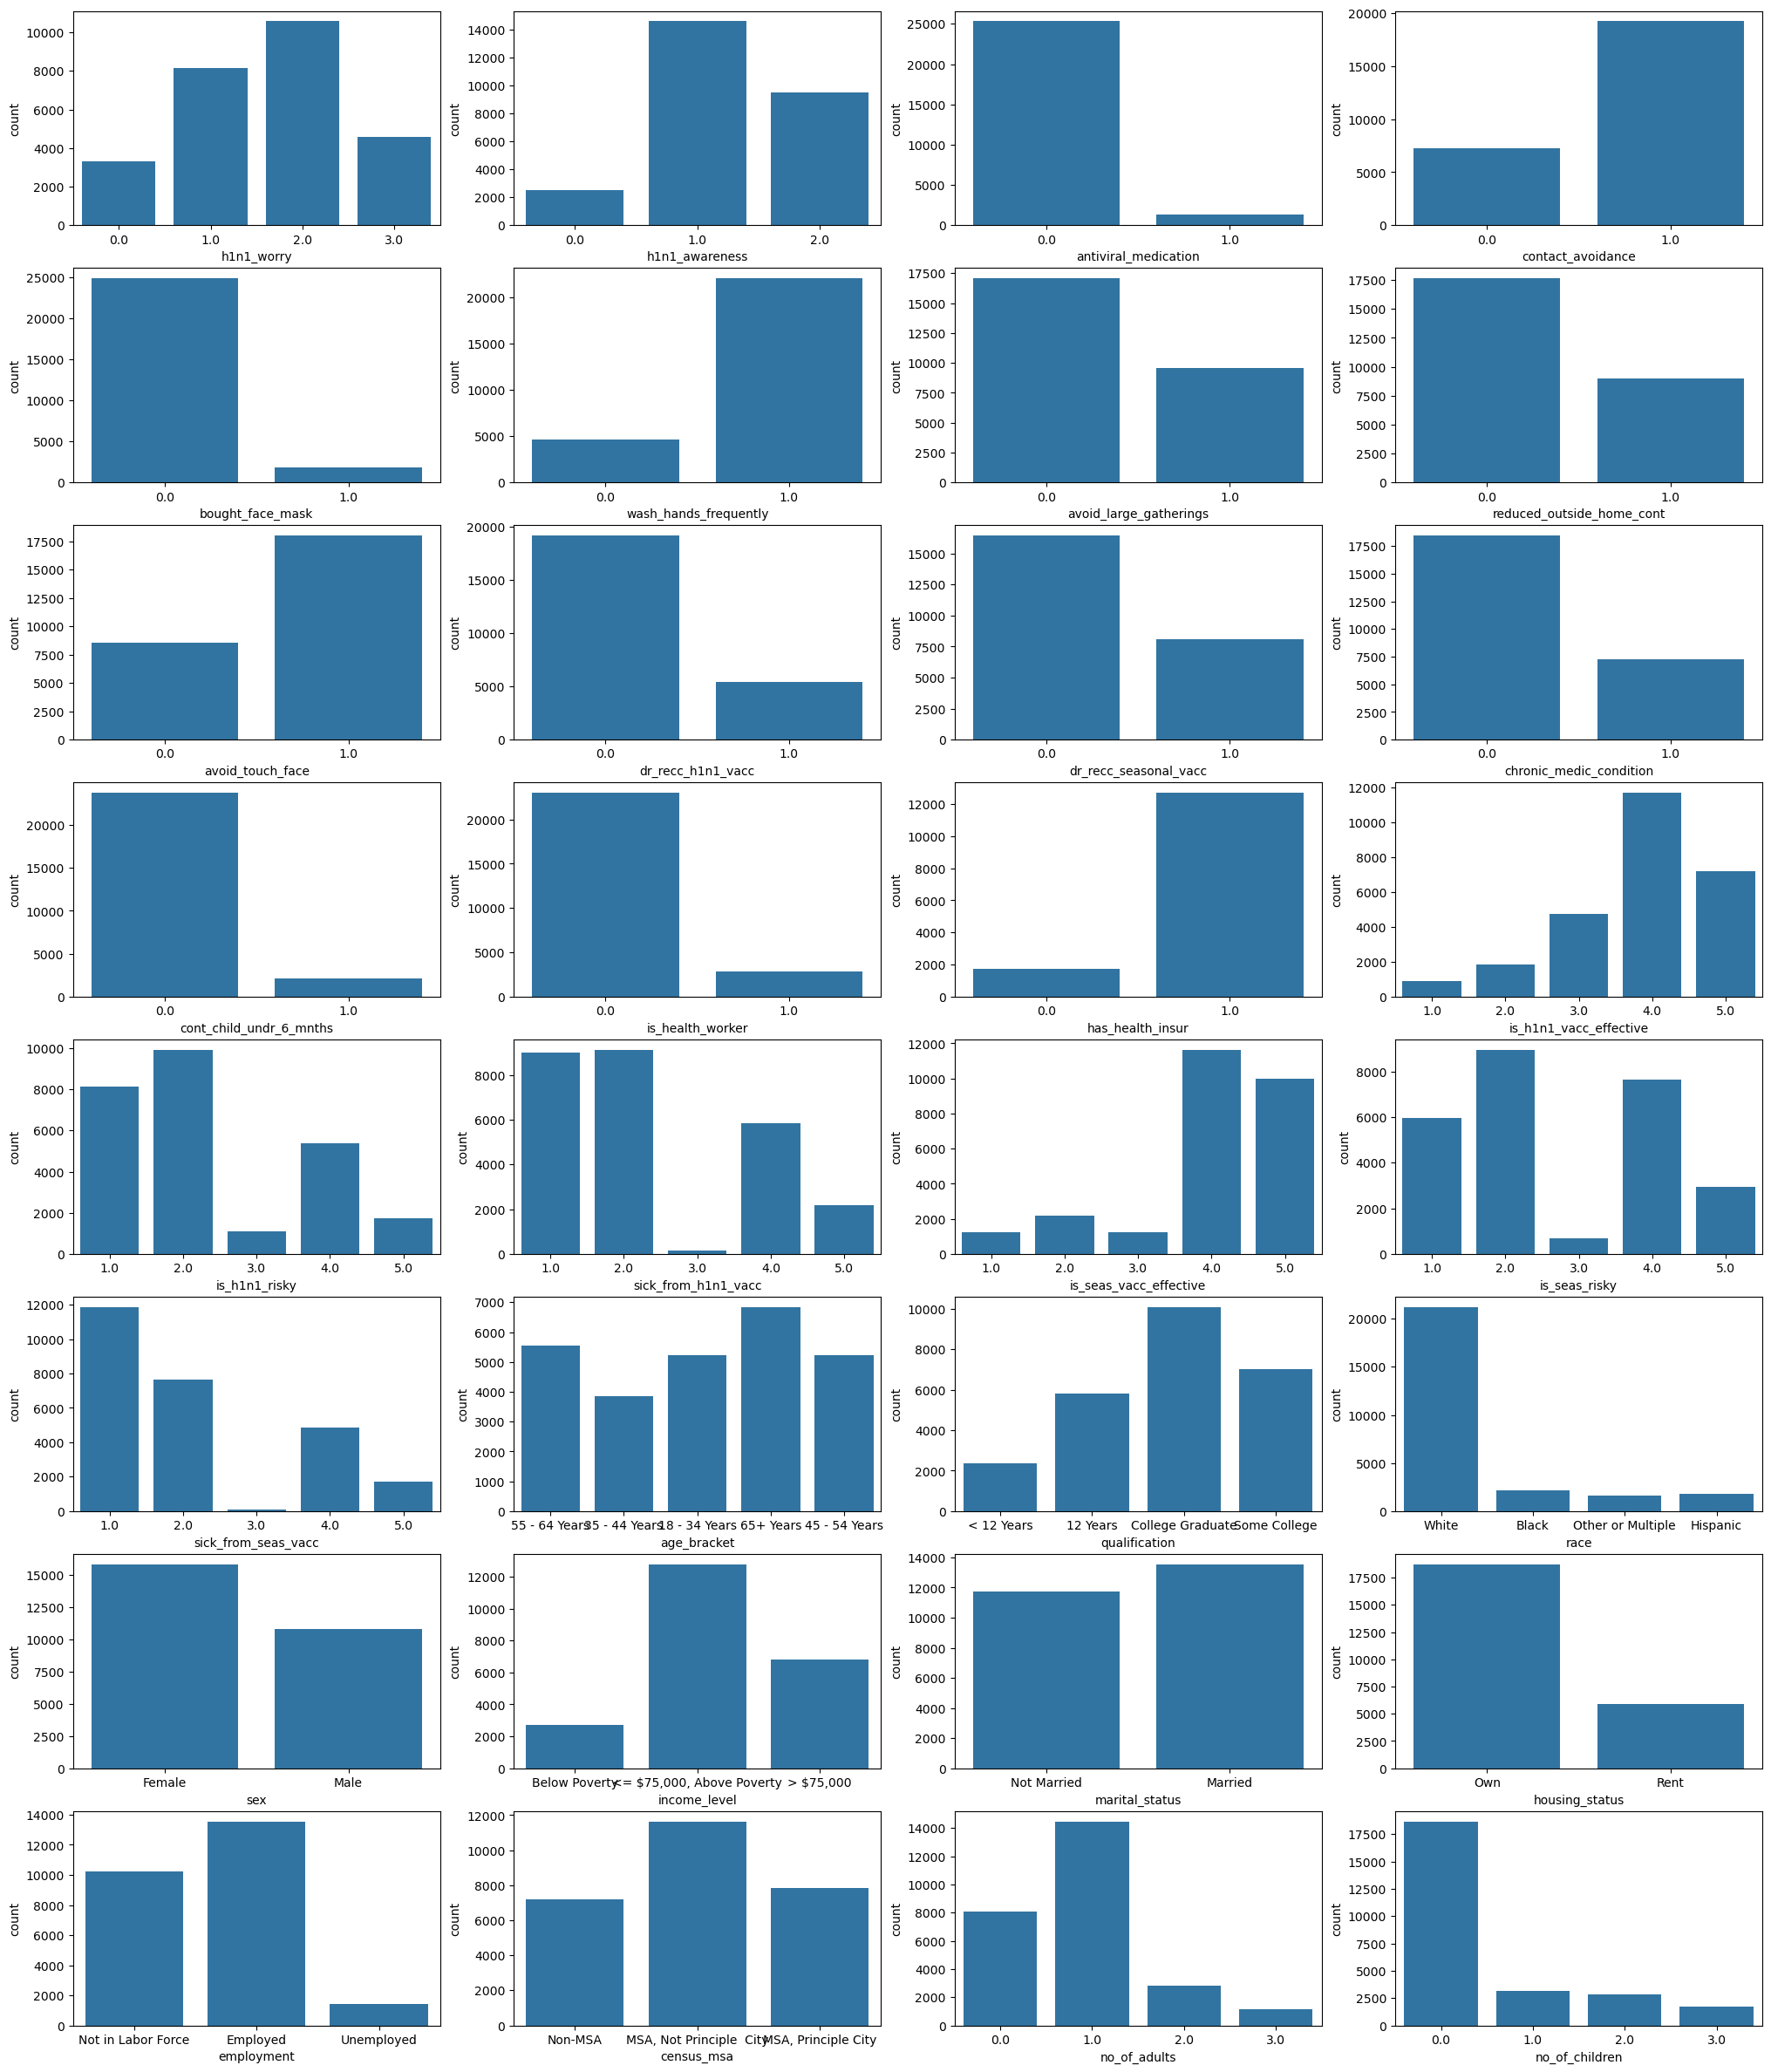

In [14]:
fig, ax = plt.subplots(nrows= 8, ncols= 4, figsize=(25,30))

for variable, subplot in zip(data_features, ax.flatten()):

    sns.countplot(x= data_features[variable], ax= subplot)

plt.show()  

In [15]:
# Most of the variables are binary. A few variables have 3, 4 and even 5 categories, as seen above.

In [16]:
# we have split the dependent variable (h1n1_vaccine) and created a dataframe 'df_target'. Use this dataframe to check the distribution of the target variable.

In [17]:
class_frequency= data_target.value_counts()
class_frequency

h1n1_vaccine
0               21033
1                5674
Name: count, dtype: int64

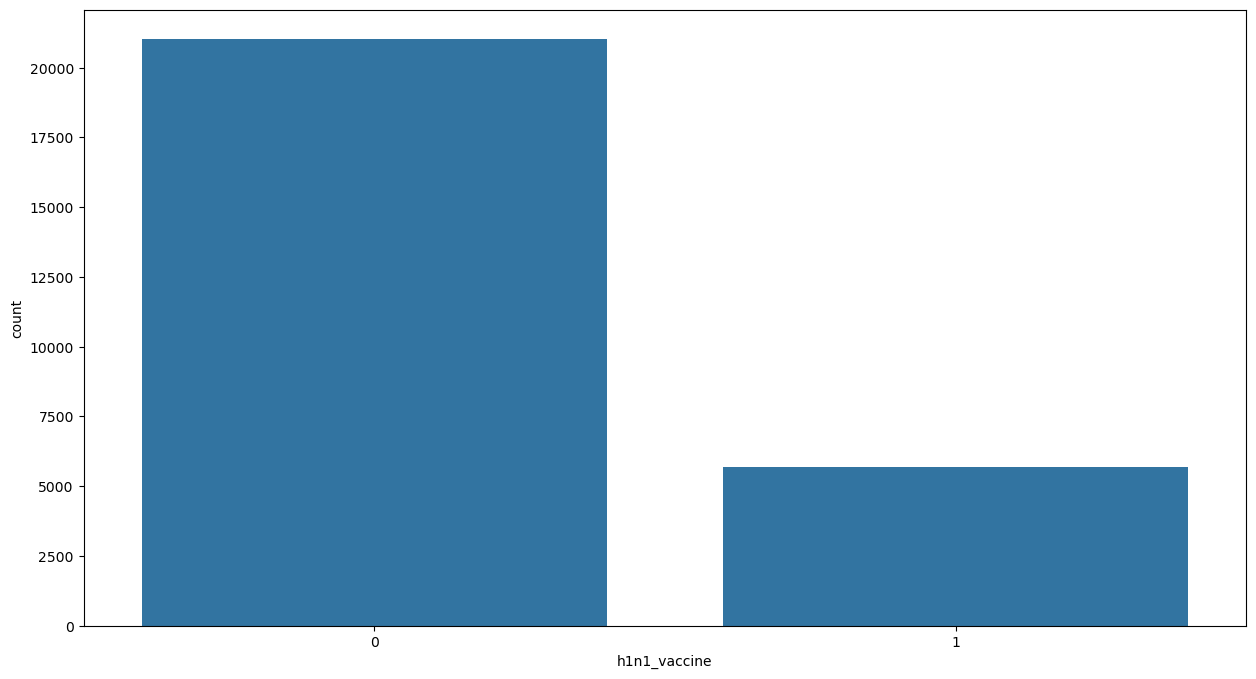

In [18]:
sns.countplot(data= data_target, x= 'h1n1_vaccine')
plt.show()

In [19]:
# There are a total of 21033 respondents who do not have taken the vaccine, and 5674 have taken the h1n1 flu vaccine. We see that the data set is  imbalanced between the two classes of the target variable.

In [20]:
# Check for missing values

Total = data.isnull().sum().sort_values(ascending= False)

Percent = (data.isnull().sum()*100 / data.isnull().count()).sort_values(ascending= False)

missing_data= pd.concat([Total, Percent], axis= 1, keys= ['Total', 'Percentage of Missing Values'])
missing_data

,Total,Percentage of Missing Values
has_health_insur,12274,45.957989
income_level,4423,16.561201
dr_recc_seasonal_vacc,2160,8.087767
dr_recc_h1n1_vacc,2160,8.087767
housing_status,2042,7.645936
employment,1463,5.477965
marital_status,1408,5.272026
qualification,1407,5.268282
chronic_medic_condition,971,3.635751
cont_child_undr_6_mnths,820,3.070356


In [21]:
# Only the variables 'age_bracket', 'race', 'sex', 'census_msa' and 'h1n1_vaccine' do not contain missing values. All other variables have missing values.

### Whole columns should be dropped only if most entries in the column are empty. In our dataset, column has_health_insur has almost 46% missing values. Column income_level has 16% missing values. Hence dropping these two columns. Also columns dr_recc_h1n1_vacc and dr_recc_seasonal_vacc have 8% missing values. Has these two columns mostly tell about doctor's recommendation and not about the respondents, I choose to drop these two columns as well. As a execrcise we can re-run the model with these two columns later.

In [22]:
data.drop(['has_health_insur','income_level','dr_recc_h1n1_vacc','dr_recc_seasonal_vacc'], axis=1, inplace=True)

In [23]:
data.shape

(26707, 29)

In [24]:
data.dropna(axis= 0, inplace= True)  # it drops all rows (axis=0) that contain any missing values (NaN)

In [25]:
data.isnull().sum()

h1n1_worry                   0
h1n1_awareness               0
antiviral_medication         0
contact_avoidance            0
bought_face_mask             0
wash_hands_frequently        0
avoid_large_gatherings       0
reduced_outside_home_cont    0
avoid_touch_face             0
chronic_medic_condition      0
cont_child_undr_6_mnths      0
is_health_worker             0
is_h1n1_vacc_effective       0
is_h1n1_risky                0
sick_from_h1n1_vacc          0
is_seas_vacc_effective       0
is_seas_risky                0
sick_from_seas_vacc          0
age_bracket                  0
qualification                0
race                         0
sex                          0
marital_status               0
housing_status               0
employment                   0
census_msa                   0
no_of_adults                 0
no_of_children               0
h1n1_vaccine                 0
dtype: int64

### 4. Data Preparation

In [26]:
data_features.columns

Index(['h1n1_worry', 'h1n1_awareness', 'antiviral_medication',
       'contact_avoidance', 'bought_face_mask', 'wash_hands_frequently',
       'avoid_large_gatherings', 'reduced_outside_home_cont',
       'avoid_touch_face', 'dr_recc_h1n1_vacc', 'dr_recc_seasonal_vacc',
       'chronic_medic_condition', 'cont_child_undr_6_mnths',
       'is_health_worker', 'has_health_insur', 'is_h1n1_vacc_effective',
       'is_h1n1_risky', 'sick_from_h1n1_vacc', 'is_seas_vacc_effective',
       'is_seas_risky', 'sick_from_seas_vacc', 'age_bracket', 'qualification',
       'race', 'sex', 'income_level', 'marital_status', 'housing_status',
       'employment', 'census_msa', 'no_of_adults', 'no_of_children'],
      dtype='object')

In [27]:
data_target.columns

Index(['h1n1_vaccine'], dtype='object')

In [28]:
# dummy encoding

data_features_dummies = pd.get_dummies(data_features, drop_first= True)
data_features_dummies 

,h1n1_worry_1.0,h1n1_worry_2.0,h1n1_worry_3.0,h1n1_awareness_1.0,h1n1_awareness_2.0,antiviral_medication_1.0,contact_avoidance_1.0,bought_face_mask_1.0,wash_hands_frequently_1.0,avoid_large_gatherings_1.0,...,employment_Not in Labor Force,employment_Unemployed,"census_msa_MSA, Principle City",census_msa_Non-MSA,no_of_adults_1.0,no_of_adults_2.0,no_of_adults_3.0,no_of_children_1.0,no_of_children_2.0,no_of_children_3.0
0,True,False,False,False,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
1,False,False,True,False,True,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,True,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,True,False,False,True,False,False,True,False,True,True,...,True,False,True,False,False,False,False,False,False,False
4,False,True,False,True,False,False,True,False,True,True,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,False,True,False,False,False,False,True,False,False,False,...,True,False,False,True,False,False,False,False,False,False
26703,True,False,False,False,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False
26704,False,True,False,False,True,False,True,True,True,True,...,False,False,False,False,False,False,False,False,False,False
26705,True,False,False,True,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False


In [29]:
data_features_dummies.shape

(26707, 67)

In [30]:
# Independent variable

x= pd.DataFrame(data_features_dummies)
x

,h1n1_worry_1.0,h1n1_worry_2.0,h1n1_worry_3.0,h1n1_awareness_1.0,h1n1_awareness_2.0,antiviral_medication_1.0,contact_avoidance_1.0,bought_face_mask_1.0,wash_hands_frequently_1.0,avoid_large_gatherings_1.0,...,employment_Not in Labor Force,employment_Unemployed,"census_msa_MSA, Principle City",census_msa_Non-MSA,no_of_adults_1.0,no_of_adults_2.0,no_of_adults_3.0,no_of_children_1.0,no_of_children_2.0,no_of_children_3.0
0,True,False,False,False,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
1,False,False,True,False,True,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,True,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,True,False,False,True,False,False,True,False,True,True,...,True,False,True,False,False,False,False,False,False,False
4,False,True,False,True,False,False,True,False,True,True,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,False,True,False,False,False,False,True,False,False,False,...,True,False,False,True,False,False,False,False,False,False
26703,True,False,False,False,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False
26704,False,True,False,False,True,False,True,True,True,True,...,False,False,False,False,False,False,False,False,False,False
26705,True,False,False,True,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False


In [31]:
# Target variable

y= pd.DataFrame(data_target)
y

,h1n1_vaccine
0,0
1,0
2,0
3,0
4,0
...,...
26702,0
26703,0
26704,0
26705,0


In [32]:
# Create a generalized function to calculate the metrics for the test set.

# create a generalized function to calculate the metrics values for test set
def get_test_report(model):
    
    # return the performace measures on test set
    return(classification_report(y_test, y_pred))

In [33]:
# Create a generalized function to calculate the kappa score for the test set.

# create a generalized function to calculate the metrics values for test set
def kappa_score(model):
    
    # return the kappa score on test set
    return(cohen_kappa_score(y_test, y_pred))
#The kappa statistic is a measure of how closely the instances classified by the machine learning
#classifier matched the data labeled as ground truth, controlling for the accuracy of a random
#classifier as measured by the expected accuracy.
#kappas > 0.75 as excellent, 0.40-0.75 as fair to good, and < 0.40 as poor.

In [34]:
# Define a function to plot the confusion matrix.

# define a to plot a confusion matrix for the model
def plot_confusion_matrix(model):
    
    # create a confusion matrix
    # pass the actual and predicted target values to the confusion_matrix()
    cm = confusion_matrix(y_test, y_pred)

    # label the confusion matrix  
    # pass the matrix as 'data'
    # pass the required column names to the parameter, 'columns'
    # pass the required row names to the parameter, 'index'
    conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'],
                               index = ['Actual:0','Actual:1'])

    # plot a heatmap to visualize the confusion matrix
    # 'annot' prints the value of each grid 
    # 'fmt = d' returns the integer value in each grid
    # 'cmap' assigns color to each grid
    # as we do not require different colors for each grid in the heatmap,
    # use 'ListedColormap' to assign the specified color to the grid
    # 'cbar = False' will not return the color bar to the right side of the heatmap
    # 'linewidths' assigns the width to the line that divides each grid
    # 'annot_kws = {'size':25})' assigns the font size of the annotated text 
    sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, linewidths = 0.1, annot_kws = {'size':25})

    # set the font size of x-axis ticks using 'fontsize'
    plt.xticks(fontsize = 20)

    # set the font size of y-axis ticks using 'fontsize'
    plt.yticks(fontsize = 20)

    # display the plot
    plt.show()

In [35]:
# Define a function to plot the ROC curve.

# define a function to plot the ROC curve and print the ROC-AUC score
def plot_roc(model):
    
    # the roc_curve() returns the values for false positive rate, true positive rate and threshold
    # pass the actual target values and predicted probabilities to the function
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    # plot the ROC curve
    plt.plot(fpr, tpr)

    # set limits for x and y axes
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])

    # plot the straight line showing worst prediction for the model
    plt.plot([0, 1], [0, 1],'r--')

    # add plot and axes labels
    # set text size using 'fontsize'
    plt.title('ROC Curve for h1n1_vaccine Classifier', fontsize = 15)
    plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
    plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)

    # add the AUC score to the plot
    # 'x' and 'y' gives position of the text
    # 's' is the text 
    # use round() to round-off the AUC score upto 4 digits
    plt.text(x = 0.02, y = 0.9, s = ('AUC Score:',round(roc_auc_score(y_test, y_pred_prob),4)))

    # plot the grid
    plt.grid(True)
    plt.show()

### Create a generalized function to create a dataframe containing the scores for the models.

In [36]:
# create an empty dataframe to store the scores for various classification algorithms
score_card = pd.DataFrame(columns=['Model', 'AUC Score', 'Precision Score', 'Recall Score',
                                   'Accuracy Score', 'Kappa Score', 'f1-score'])

# append the result table for all performance scores
# performance measures considered for comparision are 'AUC', 'Precision', 'Recall','Accuracy',
#'Kappa Score', and 'f1-score'
# compile the required information in a user defined function 
def update_score_card(model_name):
    
    # assign 'score_card' as global variable
    global score_card

    # append the results to the dataframe 'score_card'
    # 'ignore_index = True' do not consider the index labels
    score_card = score_card._append({'Model': model_name,
                                    'AUC Score' : roc_auc_score(y_test, y_pred_prob),
                                    'Precision Score': metrics.precision_score(y_test, y_pred),
                                    'Recall Score': metrics.recall_score(y_test, y_pred),
                                    'Accuracy Score': metrics.accuracy_score(y_test, y_pred),
                                    'Kappa Score': cohen_kappa_score(y_test, y_pred),
                                    'f1-score': metrics.f1_score(y_test, y_pred)}, 
                                    ignore_index = True)
    return(score_card)

### 5. Logistic Regression

### Using MLE(Maximum Likelihood estimation)

In [37]:
# Add intercept

x= sm.add_constant(x)
x

,const,h1n1_worry_1.0,h1n1_worry_2.0,h1n1_worry_3.0,h1n1_awareness_1.0,h1n1_awareness_2.0,antiviral_medication_1.0,contact_avoidance_1.0,bought_face_mask_1.0,wash_hands_frequently_1.0,...,employment_Not in Labor Force,employment_Unemployed,"census_msa_MSA, Principle City",census_msa_Non-MSA,no_of_adults_1.0,no_of_adults_2.0,no_of_adults_3.0,no_of_children_1.0,no_of_children_2.0,no_of_children_3.0
0,1.0,True,False,False,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
1,1.0,False,False,True,False,True,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,1.0,True,False,False,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
3,1.0,True,False,False,True,False,False,True,False,True,...,True,False,True,False,False,False,False,False,False,False
4,1.0,False,True,False,True,False,False,True,False,True,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,1.0,False,True,False,False,False,False,True,False,False,...,True,False,False,True,False,False,False,False,False,False
26703,1.0,True,False,False,False,True,False,True,False,True,...,False,False,True,False,True,False,False,False,False,False
26704,1.0,False,True,False,False,True,False,True,True,True,...,False,False,False,False,False,False,False,False,False,False
26705,1.0,True,False,False,True,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False


In [38]:
# split data to train and test

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.30, random_state= 10)

# print dimension of train set
print("X_train",x_train.shape)
print("y_train",y_train.shape)

# print dimension of test set
print("X_test",x_test.shape)
print("y_test",y_test.shape)

X_train (18694, 68)
y_train (18694, 1)
X_test (8013, 68)
y_test (8013, 1)


In [39]:
# Build a logistic regression model using statsmodels `Logit()`

log_reg_model= sm.Logit(y_train, x_train.astype(int)).fit()

print(log_reg_model.summary())

Optimization terminated successfully.
         Current function value: 0.358028
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           h1n1_vaccine   No. Observations:                18694
Model:                          Logit   Df Residuals:                    18626
Method:                           MLE   Df Model:                           67
Date:                Sat, 19 Sep 2026   Pseudo R-squ.:                  0.3085
Time:                        12:13:51   Log-Likelihood:                -6693.0
converged:                       True   LL-Null:                       -9679.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -4.0030      0.209    -19.165     

In [40]:
# The `Pseudo R-squ.` obtained from the above model summary is the value of `McFadden's R-squared`.

In [41]:
# Prediction on test set

y_pred_prob = log_reg_model.predict(x_test.astype(int))
y_pred_prob

2653     0.057031
9506     0.099244
23107    0.042874
22648    0.042163
25589    0.462404
           ...   
6273     0.139132
9671     0.093265
1301     0.046065
21048    0.632336
17388    0.579824
Length: 8013, dtype: float64

### Since the target variable can take only two values either 0 or 1. We decide the threshold of 0.5. If `y_pred_prob` is less than 0.5, then consider it to be 0 else consider it to be 1.

In [42]:
# convert probabilities to 0 and 1 using 'if_else'

y_pred = ['0' if x < 0.5 else '1' for x in y_pred_prob]

# convert the predicted values to type 'float32'
y_pred = np.array(y_pred, dtype=np.float32)
y_pred

array([0., 0., 0., ..., 0., 1., 1.], dtype=float32)

### 6. Calculate the performance measures.

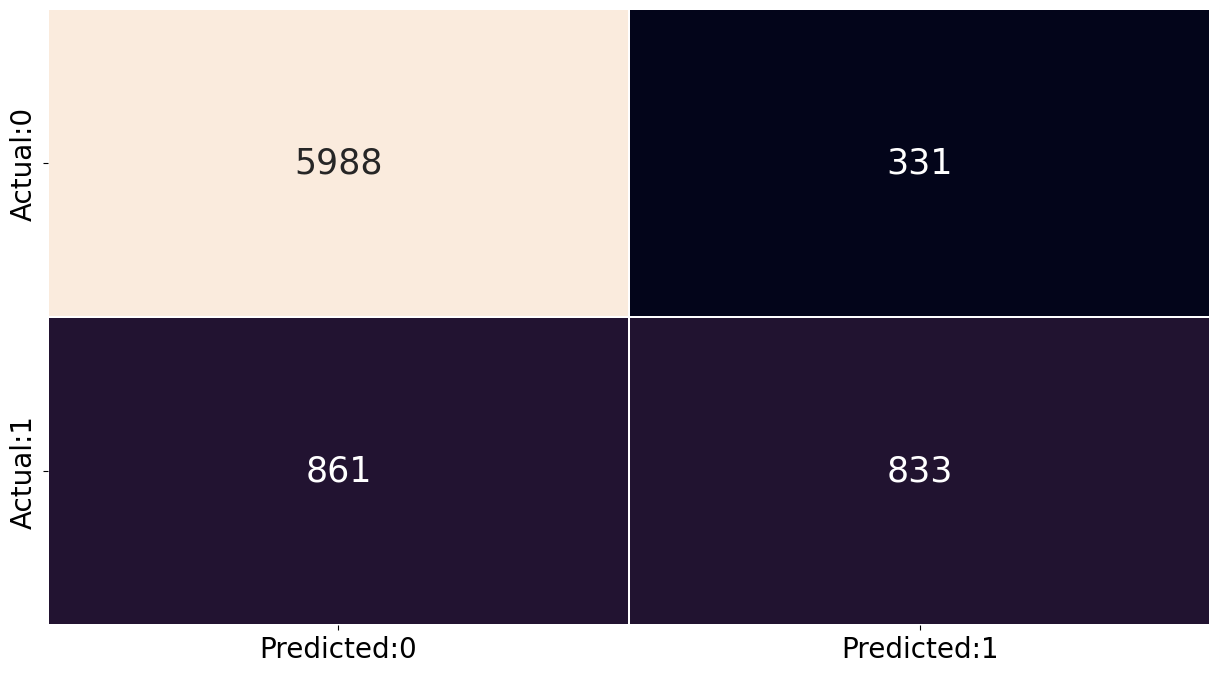

In [43]:
# Confusion matrix

# call the function to plot the confusion matrix
# pass the logistic regression model to the function
plot_confusion_matrix(log_reg_model)

In [44]:
# compute the performance measures on test data
# call the function 'get_test_report'
# pass the logstic regression model to the function
test_report = get_test_report(log_reg_model)

# print the performace measures
print(test_report)

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      6319
           1       0.72      0.49      0.58      1694

    accuracy                           0.85      8013
   macro avg       0.79      0.72      0.75      8013
weighted avg       0.84      0.85      0.84      8013



### The accuracy is 85% for this model. Also, there is significant difference between specificity and sensitivity.

In [45]:
# compute kappa score on test set
# call the function 'kappa_score'
# pass the logstic regression model to the function
kappa_value = kappa_score(log_reg_model)

# print the kappa value
print(kappa_value)

0.49616326437600866


### As the kappa score for the logistic regression is 0.4961, we can say that there is moderate agreement between the  actual and predicted values.

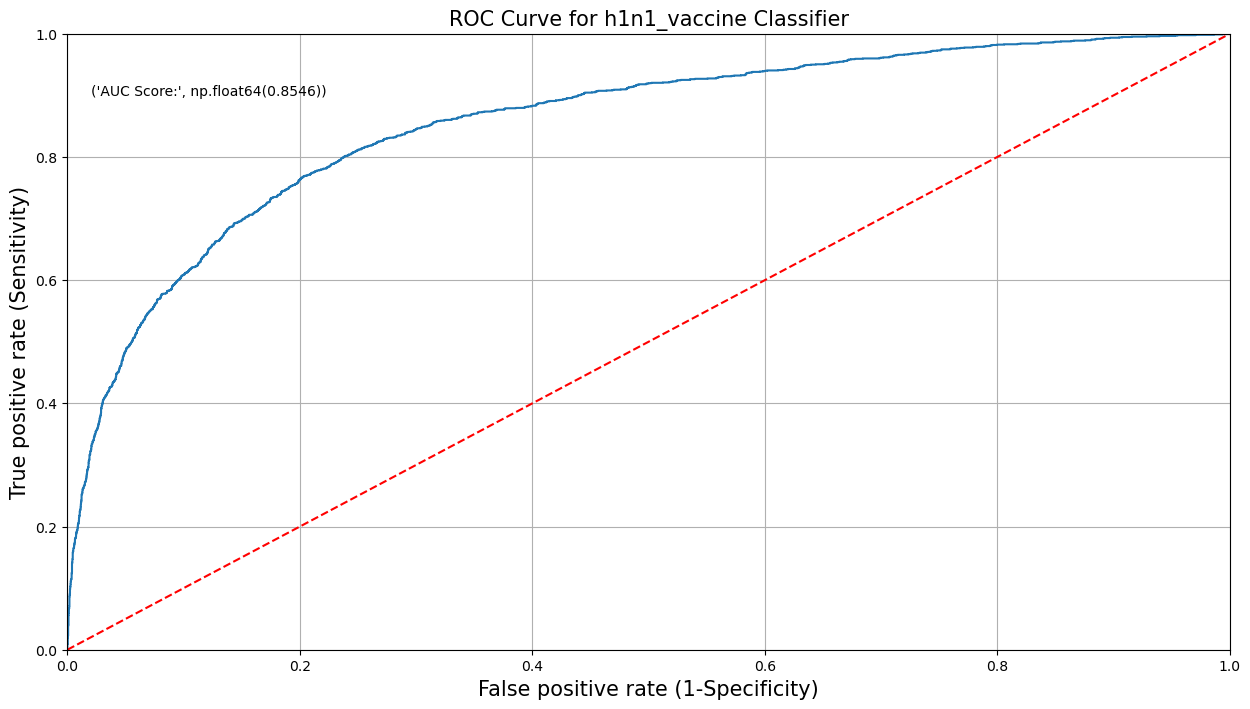

In [46]:
# call the function 'plot_roc' to plot the ROC curve
# pass the logstic regression model to the function
plot_roc(log_reg_model)

### The dotted line represents the ROC curve of a purely random classifier; a good classifier stays as far away from that line as possible (toward the top-left corner).
### We see our classifier (logistic regression) to be away from the dotted line with the AUC score 0.8546.

In [47]:
# use the function 'update_score_card' to store the performance measures
# pass the 'Logistic Regression' as model name to the function

update_score_card(model_name = 'Logistic Regression')

,Model,AUC Score,Precision Score,Recall Score,Accuracy Score,Kappa Score,f1-score
0,Logistic Regression,0.854585,0.715636,0.491736,0.851242,0.496163,0.582925


### It can be seen from the result tabulation, that most of the accuracy measures for logistic regression (without scaled features) and logistic regression with scaled features are nearly equal. This implies that there is no significant difference between the model with scaled features and unscaled features.

### Logistic Regression (using SGD)

#### The `SGDClassifier()` from sklearn contains an intercept term. Thus, there is no need to add the column of intercept.

In [48]:
# instantiate the 'SGDClassifier' to build model using SGD
# to perform logistic regression, consider the log-loss function 
# set 'random_state' to generate the same dataset each time you run the code 
SGD = SGDClassifier(loss = 'log_loss', random_state = 10)

# The 'log' loss gives logistic regression, a probabilistic  
# fit the model on scaled training data
logreg_with_SGD = SGD.fit(x_train, y_train)

In [49]:
# predict probabilities on the test set
# consider the probability of positive class by subsetting with '[:,1]'
y_pred_prob = logreg_with_SGD.predict_proba(x_test)[:,1]
y_pred_prob

array([0.05462432, 0.0596302 , 0.03351085, ..., 0.0334146 , 0.4175697 ,
       0.45084638])

In [50]:
# use predict() to predict the class labels of target variable
y_pred = logreg_with_SGD.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

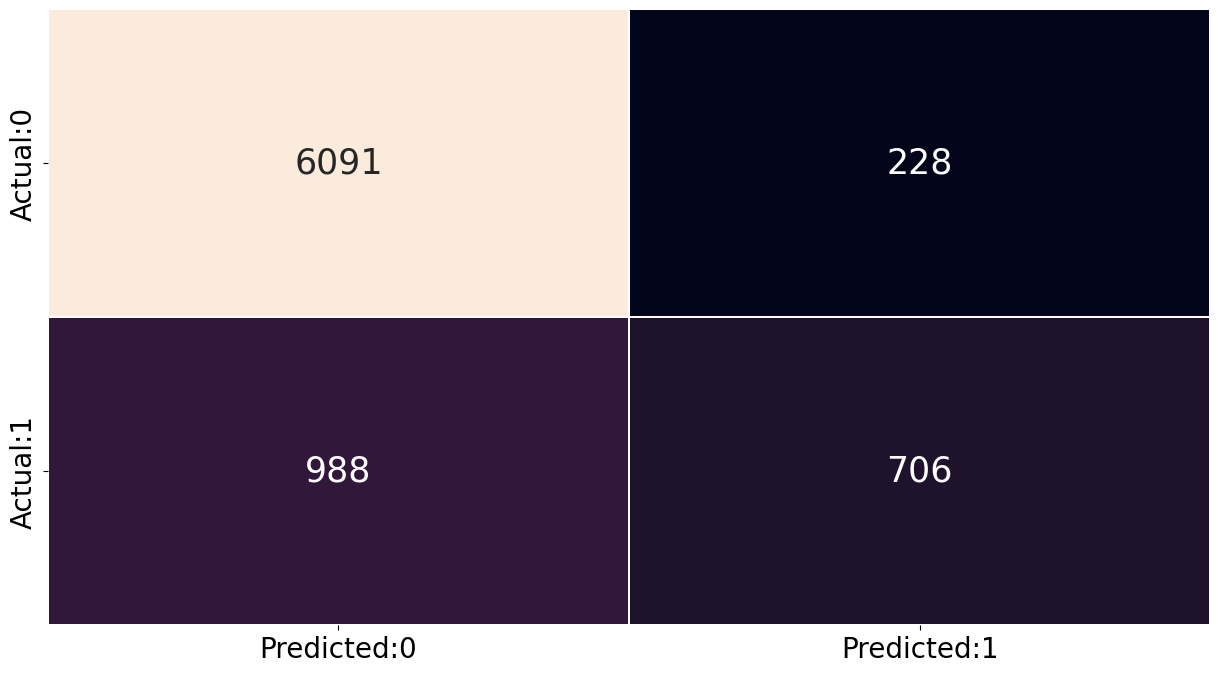

In [51]:
# call the function to plot the confusion matrix
# pass the logistic regression (SGD) model to the function
plot_confusion_matrix(logreg_with_SGD)

In [52]:
# compute the performance measures on test data
# call the function 'get_test_report'
# pass the logstic regression (SGD) model to the function
test_report = get_test_report(logreg_with_SGD)

# print the performace measures
print(test_report)

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      6319
           1       0.76      0.42      0.54      1694

    accuracy                           0.85      8013
   macro avg       0.81      0.69      0.72      8013
weighted avg       0.84      0.85      0.83      8013



### Accuracy is 85%.

In [53]:
# compute kappa score on test set
# call the function 'kappa_score'
# pass the logstic regression (SGD) model to the function
kappa_value = kappa_score(logreg_with_SGD)

# print the kappa value
print(kappa_value)

0.45546372223810616


#### As the kappa score for the logistic regression (SGD) is 0.4554, we can say that there is moderate agreement between the actual and predicted values.

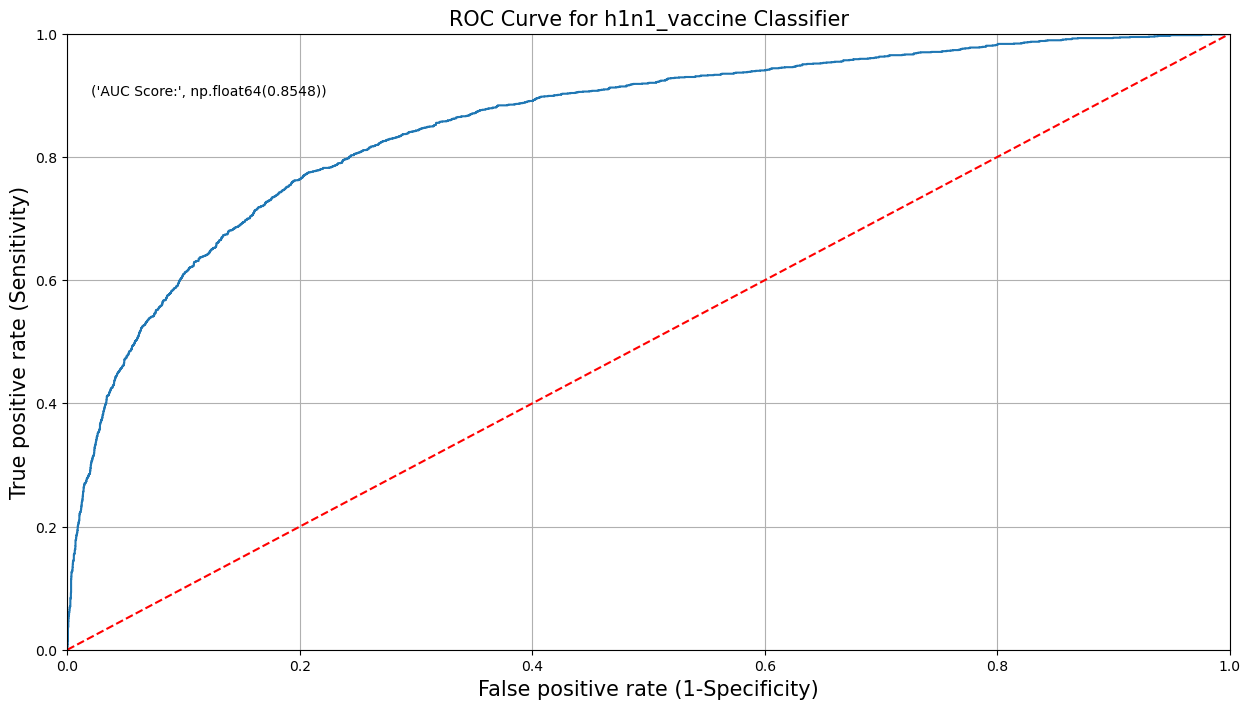

In [54]:
# call the function 'plot_roc' to plot the ROC curve
# pass the logstic regression (SGD) model to the function
plot_roc(logreg_with_SGD)

In [55]:
# use the function 'update_score_card' to store the performance measures
# pass the 'Logistic Regression (SGD)' as model name to the function
update_score_card(model_name = 'Logistic Regression (SGD)')

,Model,AUC Score,Precision Score,Recall Score,Accuracy Score,Kappa Score,f1-score
0,Logistic Regression,0.854585,0.715636,0.491736,0.851242,0.496163,0.582925
1,Logistic Regression (SGD),0.854754,0.755889,0.416765,0.848247,0.455464,0.537291


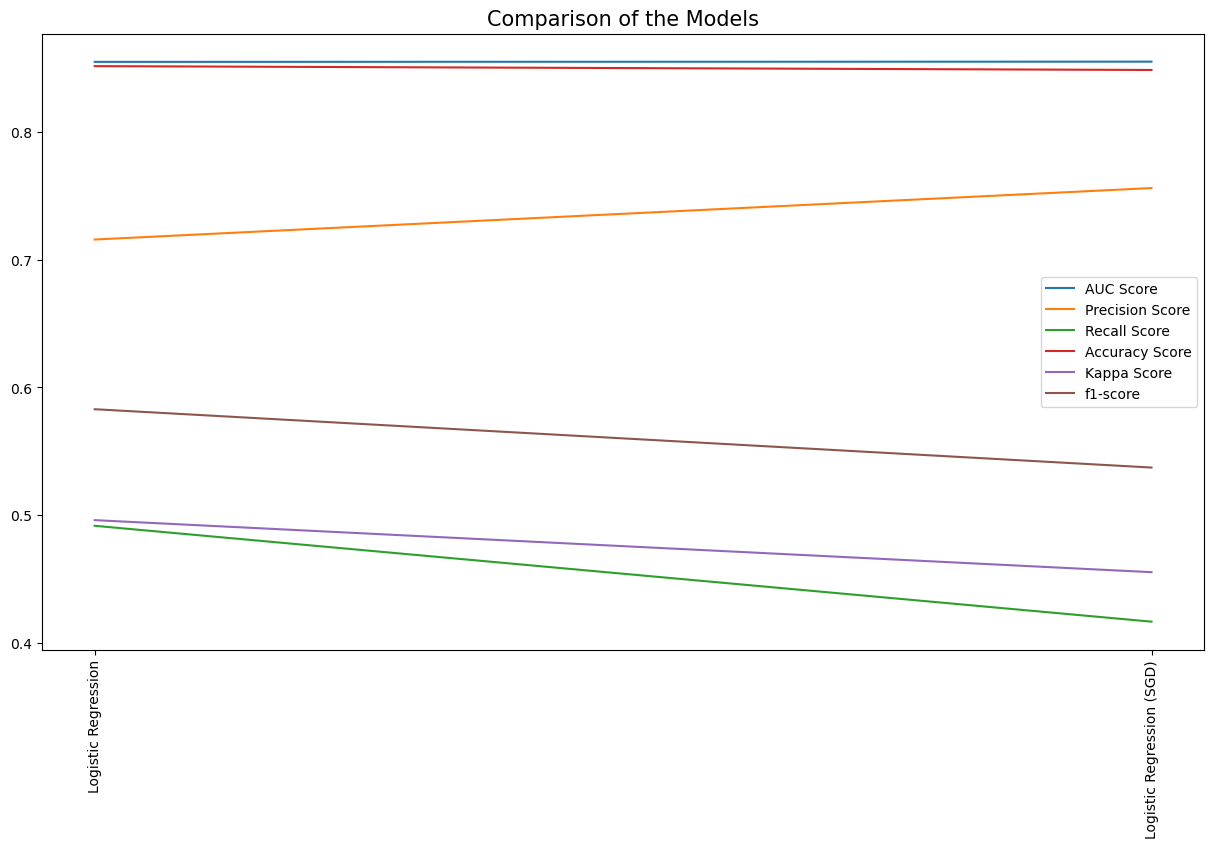

In [56]:
# plot the graph
# by default, plot() returns the line plot
score_card.plot()

# set the text size of the title
plt.title(label = 'Comparison of the Models', fontsize = 15)

# set the model names as x-ticks
# 'score_card.Model' retuns the model names
# rotate the x-axis labels vertically
plt.xticks([0,1], list(score_card.Model), rotation = 'vertical')

# display the plot
plt.show()

#### The above plot shows that the Logistic Regression(SGD) model has lower values for Recall Score, Kappa score and F1-score when compared to the Logistic Regression model built initially. All the other performance measures are similar for both the models. Finally, it can be concluded that the Logistic Regression model can be used to predict if a person has taken a h1n1 vaccine or not. Additionally, based on the business decision, as to what is more important to predict correctly for business,i.e., predicting the people who have taken the vaccine is more important or whether it is more important to predict the people who have not taken the vaccine. Based on business decision the performance parameters like sensitivity or specificity can be fine tuned.

## Save model

In [58]:
import joblib

joblib.dump(logreg_with_SGD, "vaccine_model.pkl")

['vaccine_model.pkl']